In [1]:
!nvidia-smi

Fri Mar 27 15:42:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             31W /  250W |     299MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Imports

In [2]:
# PyTorch settings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, random_split, Subset

# Data Handling
import numpy as np
import pandas as pd

# Image display
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

# utils
import os
import time
import json
import shutil
from pathlib import Path
from random import randint
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Root Path

In [3]:
root_path = Path.cwd()

# Exploratory Data Analysis

In [4]:
class ViewAlphabets:
    def __init__(self, alpha_dir):
        self.class_dir = alpha_dir
        self.items = sorted(list(self.class_dir.iterdir()))
        
    def _display_image(self, file):
        img = Image.open(file)
        plt.imshow(img)
        plt.axis("off")
        plt.show()

    def visualize_letters(self, img_count):
        for item in self.items:
            # print(item, item.name, type(item.name))
            files = list(item.iterdir())
            file_count = len(files)
            rand_img_idx = randint(0, file_count)
            print(item.name)
            for file in files[rand_img_idx : min(rand_img_idx + img_count, file_count)]:
                self._display_image(file)

    def get_len(self):
        return len(self.items)
        

alpha_dir = root_path / "alphabet_dataset" 
va = ViewAlphabets(alpha_dir)
# va.visualize_letters(1)

# Hyperparameters

In [21]:
BATCH_SIZE = 64
TRAIN_VAL_RATIO = 0.8
IMAGE_RESIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 1e-3
EPOCHS = 100

# Available Device

In [6]:
print(DEVICE)

cuda


# Load Alphabet Images

In [ ]:
# Implement some augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_RESIZE, IMAGE_RESIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_RESIZE, IMAGE_RESIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(alpha_dir, transform=train_transforms)
class_names = full_dataset.classes
num_train = int(len(full_dataset)*TRAIN_VAL_RATIO)
num_val = int(len(full_dataset)) - num_train

# Split the data sets randomly according to their counts
g = torch.Generator().manual_seed(42)
train_dataset,val_dataset = torch.utils.data.random_split(
    full_dataset, 
    [num_train, num_val],
    generator=g
)

val_dataset.dataset.transform = val_transforms

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# inspect train loader
images, label = next(iter(train_loader))
print(images.shape, label)


num_classes = len(class_names)

torch.Size([64, 3, 32, 32]) tensor([34, 10, 22,  9, 23,  6,  7,  7,  1,  5, 14, 50, 24, 31, 39, 19, 46, 49,
        33, 47, 49, 34, 41,  3, 31, 45,  3, 19, 50, 20, 49, 49, 36, 14, 42, 31,
        32, 42, 13, 36, 21, 30, 38, 17, 25, 44, 23, 24, 21,  3,  6,  3, 47, 34,
        17, 24, 36, 35, 35, 47,  3, 35, 10, 43])


# Save Class Names

In [10]:
class_names_path = root_path / "class_names.json"
with open(class_names_path, "w") as f:
    json.dump([cn[0] for cn in class_names], f)

# Custom CNN Architecture

In [11]:
class CustomCNN(nn.Module):
    def __init__(self,  num_classes, in_channel=3):
        super ().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channel, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        ) 

        self.block_2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.4),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
        )

        # ── Classification head ──────────────────────────────
        self.head = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),

            nn.Flatten(),
            nn.LazyLinear(num_classes),  # infers in_features automatically
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.head(x)

# Metrics

In [12]:
class ComputeMetrics:

    @staticmethod
    def compute_confusion_matrix(labels, predictions, num_classes):
        cm = np.zeros((num_classes, num_classes), dtype=int)

        for l, p in zip(labels, predictions):
            cm[l, p] += 1

        return cm

    @staticmethod
    def accuracy(cm):
        return np.trace(cm) / np.sum(cm)

    @staticmethod
    def precision(cm):
        diagonal = np.diag(cm)
        predicted = np.sum(cm, axis=0)

        return np.divide(
            diagonal,
            predicted,
            out=np.zeros_like(diagonal, dtype=float),
            where=predicted != 0
        )

    @staticmethod
    def recall(cm):
        diagonal = np.diag(cm)
        actual = np.sum(cm, axis=1)

        return np.divide(
            diagonal,
            actual,
            out=np.zeros_like(diagonal, dtype=float),
            where=actual != 0
        )

    @staticmethod
    def f1(precision, recall):
        return np.divide(
            2 * precision * recall,
            precision + recall,
            out=np.zeros_like(precision),
            where=(precision + recall) != 0
        )
    @staticmethod
    def model_parameter_count(model):
        return sum(p.numel() for p in model.parameters())

# Data Management

In [13]:
class DataManager:
    def __init__(self, file_path):
        self.file_path = Path(file_path)
        
    def create_csv(self, column_list):
        if self.file_path.exists():
            print(f"{self.file_path} already exists")
            return
            
        df = pd.DataFrame(columns=column_list)
        df.to_csv(self.file_path, index=False)

    def append_data(self, new_data):
        if not self.file_path.exists():
            print(f"{self.file_path} does not exist")
            return

        df_column = pd.read_csv(self.file_path, nrows=0)
        column_names = df_column.columns.tolist()
        new_data_columns = list(new_data.keys())
        
        if set(column_names) != set(new_data_columns):
            print(f"The new data column names :{new_data_columns} does not match the csv column names: {column_names}")
            return
            
        new_df = pd.DataFrame([new_data])
        new_df = new_df[column_names]
        new_df.to_csv(self.file_path, mode="a", index=False, header=False)

    def get_df(self):
        return pd.read_csv(self.file_path)

    def get_last_row(self):
        return pd.read_csv(self.file_path).tail(1)

    def get_start_epoch(self):
        last_row = self.get_last_row()
    
        if last_row.empty:
            return 0
    
        return last_row.iloc[0]["epoch"]

# Delete Folder

In [14]:
def delete_folder(folder):
    if folder.exists() and folder.is_dir():
        shutil.rmtree(folder)


# Graph Plotting

In [15]:
class PlotGraph:
    def __init__(self, row_count, col_count):
        self.fig = plt.figure(figsize=(20,40))
        self.gs = GridSpec(row_count, col_count, figure=self.fig)
        
    def train_val_plot(self, ax, train_data, val_data, label_train, label_val, epochs, title):
        ax.plot(epochs, train_data, marker=None, label=label_train)
        ax.plot(epochs, val_data, marker=None, label=label_val)
        ax.grid(True, alpha=0.2)
        if len(epochs) > 0:
            ax.set_xlim(0, int(epochs[-1]) + 1)
        ax.set_title(title)
        ax.legend()

    def plot_confusion_matrix(self, ax, cm, class_names=None):
        im = ax.imshow(cm)

        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        if class_names:
            ax.set_xticks(np.arange(len(class_names)))
            ax.set_yticks(np.arange(len(class_names)))
            ax.set_xticklabels(class_names)
            ax.set_yticklabels(class_names)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, 
                    cm[i, j], 
                    fontsize=5,
                    ha="center", 
                    va="center")

        plt.title("Confusion Matrix")
        # fig, axes = plt.subplots(figsize=(12, 8))

# Model Manager

In [16]:
class ModelManager:
    def __init__(self, model, optimizer, device):
        self.model = model
        self.optimizer = optimizer
        self.device = device

    def save_cur_model(self, model_path):
        torch.save({
            "model" : self.model.state_dict(),
            "optimizer" : self.optimizer.state_dict()
        }, model_path)

    def save_best_model(self, best_model_path):
        torch.save({
            "model" : self.model.state_dict(),
            "optimizer" : self.optimizer.state_dict()
        }, best_model_path)

    def load_cur_model(self, model_path):
        if model_path.exists():
            checkpoint = torch.load(model_path, map_location=self.device)
            self.model.load_state_dict(checkpoint["model"])
            self.optimizer.load_state_dict(checkpoint["optimizer"])
        

# Training Setup

In [17]:
class TrainSetup:
    def __init__(self,model, learning_rate, class_names, epochs, device):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        self.criterion = nn.CrossEntropyLoss()
        self.epochs = epochs
        self.class_names = class_names 
        self.num_classes = len(self.class_names)

    def train(self, train_loader):
        self.model.train()
        running_loss, total  = 0.0, 0

        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad() # reset the gradient of all parameters

            outputs = self.model(images) # forward pass 

            loss = self.criterion(outputs, labels) # compute loss 
            loss.backward() # compute gradients (backpropagate)

            self.optimizer.step() # update weights

            running_loss += loss.item() * images.size(0)

            total += labels.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        confusion_matrix = ComputeMetrics.compute_confusion_matrix(all_labels, all_preds, self.num_classes)
        return running_loss / total, confusion_matrix
    
    @torch.no_grad()
    def val(self, val_loader):
        self.model.eval()
        running_loss, total = 0.0, 0
        all_preds = []
        all_labels = []
        for images, labels in val_loader:
            images, labels = images.to(self.device), labels.to(self.device)
            logits = self.model(images) # inference

            loss = self.criterion(logits, labels)
            running_loss += loss.item() * images.size(0)

            total += labels.size(0)

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        cm = ComputeMetrics.compute_confusion_matrix(all_labels, all_preds, self.num_classes)
        return running_loss / total, cm

    def begin_training(self, train_loader, val_loader, csv_file_path, model_path, best_model_path, metrics):
        mm = ModelManager(self.model, self.optimizer, self.device)
        mm.load_cur_model(model_path)
        dm = DataManager(csv_file_path)
        dm.create_csv(metrics)
        
        start_epoch = int(dm.get_start_epoch())
        
        print(f"Starting from Epoch [{start_epoch + 1}/{self.epochs}]")
        
        df = dm.get_df()
        best_accuracy = 0.0 if df.empty else df["val_accuracy"].max()
        best_f1 = 0.0 if df.empty else df["val_f1"].max()
        best_loss = 0.0 if df.empty else df["val_loss"].min()
        early_stop = 0 if df.empty else df["early_stop"].tail()

        for epoch in range(start_epoch, self.epochs):
            new_data = {"epoch" : epoch + 1}
            
            # Loss
            torch.cuda.synchronize()
            start = time.perf_counter()
            train_loss, train_cm = self.train(train_loader)
            torch.cuda.synchronize()
            train_time  = time.perf_counter() - start
            new_data["train_time"] = train_time
            
            val_loss, val_cm = self.val(val_loader)
            new_data["train_loss"] = train_loss
            new_data["val_loss"] = val_loss
            
            # Accuracy
            train_accuracy = ComputeMetrics.accuracy(train_cm)
            val_accuracy = ComputeMetrics.accuracy(val_cm)
            new_data["train_accuracy"] = train_accuracy
            new_data["val_accuracy"] = val_accuracy
            
            # Precision
            train_precision = ComputeMetrics.precision(train_cm).mean()
            val_precision = ComputeMetrics.precision(val_cm).mean()
            new_data["train_precision"] = train_precision
            new_data["val_precision"] = val_precision
            
            # Recall
            train_recall = ComputeMetrics.recall(train_cm).mean()
            val_recall = ComputeMetrics.recall(val_cm).mean()
            new_data["train_recall"] = train_recall
            new_data["val_recall"] = val_recall
            
            # F1-Score
            train_f1 = ComputeMetrics.f1(train_precision, train_recall)
            val_f1 = ComputeMetrics.f1(val_precision, val_recall)
            new_data["train_f1"] = train_f1
            new_data["val_f1"] = val_f1

            # Save best model weights
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                mm.save_best_model(best_model_path)
                early_stop = 0
            else:
                early_stop += 1

            new_data["early_stop"] = early_stop # Update early stopping
            
            dm.append_data(new_data) # append data to csv file
                
            mm.save_cur_model(model_path) # save model weights and optimizer 

            # Plot Progress
            pg = PlotGraph(4,2)
            df = dm.get_df()
            ax1 = pg.fig.add_subplot(pg.gs[0,0])
            pg.train_val_plot(
                ax1, 
                df["train_accuracy"].to_numpy(), 
                df["val_accuracy"].to_numpy(), 
                f"Train Accuracy: {train_accuracy:.4f}", f"Val Accuracy: {val_accuracy:.4f}",
                df["epoch"].to_numpy(),
                "Accuracy"
            )
            ax2 = pg.fig.add_subplot(pg.gs[0,1])
            pg.train_val_plot(
                ax2,
                df["train_loss"].to_numpy(), 
                df["val_loss"].to_numpy(), 
                f"Train Loss: {train_loss:.4f}", f"Val Loss: {val_loss:.4f}",
                df["epoch"].to_numpy(),
                "Loss"
            )
            ax3 = pg.fig.add_subplot(pg.gs[1,0])
            
            pg.train_val_plot(
                ax3,
                df["train_f1"].to_numpy(), 
                df["val_f1"].to_numpy(), 
                f"Train F1-Score: {train_f1:.4f}", f"Val F1-Score: {val_f1:.4f}",
                df["epoch"].to_numpy(),
                "F1-Score"
            )
            ax4 = pg.fig.add_subplot(pg.gs[1,1])
            pg.train_val_plot(
                ax4,
                df["train_precision"].to_numpy(), 
                df["val_precision"].to_numpy(), 
                f"Train Precision: {train_f1:.4f}", f"Val Precision: {val_f1:.4f}",
                df["epoch"].to_numpy(),
                "Precision"
            )
            ax5 = pg.fig.add_subplot(pg.gs[2,0])
            pg.train_val_plot(
                ax5,
                df["train_recall"].to_numpy(), 
                df["val_recall"].to_numpy(), 
                f"Train Recall: {train_recall:.4f}", f"Val Recall: {val_recall:.4f}",
                df["epoch"].to_numpy(),
                "Recall"
            )
            ax6 = pg.fig.add_subplot(pg.gs[3,:])
            ax6.set_box_aspect(1)
            pg.plot_confusion_matrix(
                ax6,
                val_cm,
                self.class_names
            )
            
            clear_output(wait=True)
            plt.show()
            plt.tight_layout()
            
            print(
                f"Epoch [{epoch+1}/{self.epochs}] \n"
                f"Train Loss: {train_loss:.4f} \n"
                f"Val Loss: {val_loss:.4f} \n"
                f"Best Accuracy: {best_accuracy:.2f} \n"
                f"Training Time: {train_time:.2f} seconds \n"
                f"Early Stopping: {early_stop}"
            )

# Deep Learning Model Functions

In [18]:
def custom_cnn():
    model = CustomCNN(num_classes=num_classes)
    return model

# Delete Folder if required

In [ ]:
# folder = root_path /"models"/"custom_cnn"
# delete_folder(folder)

<Figure size 640x480 with 0 Axes>

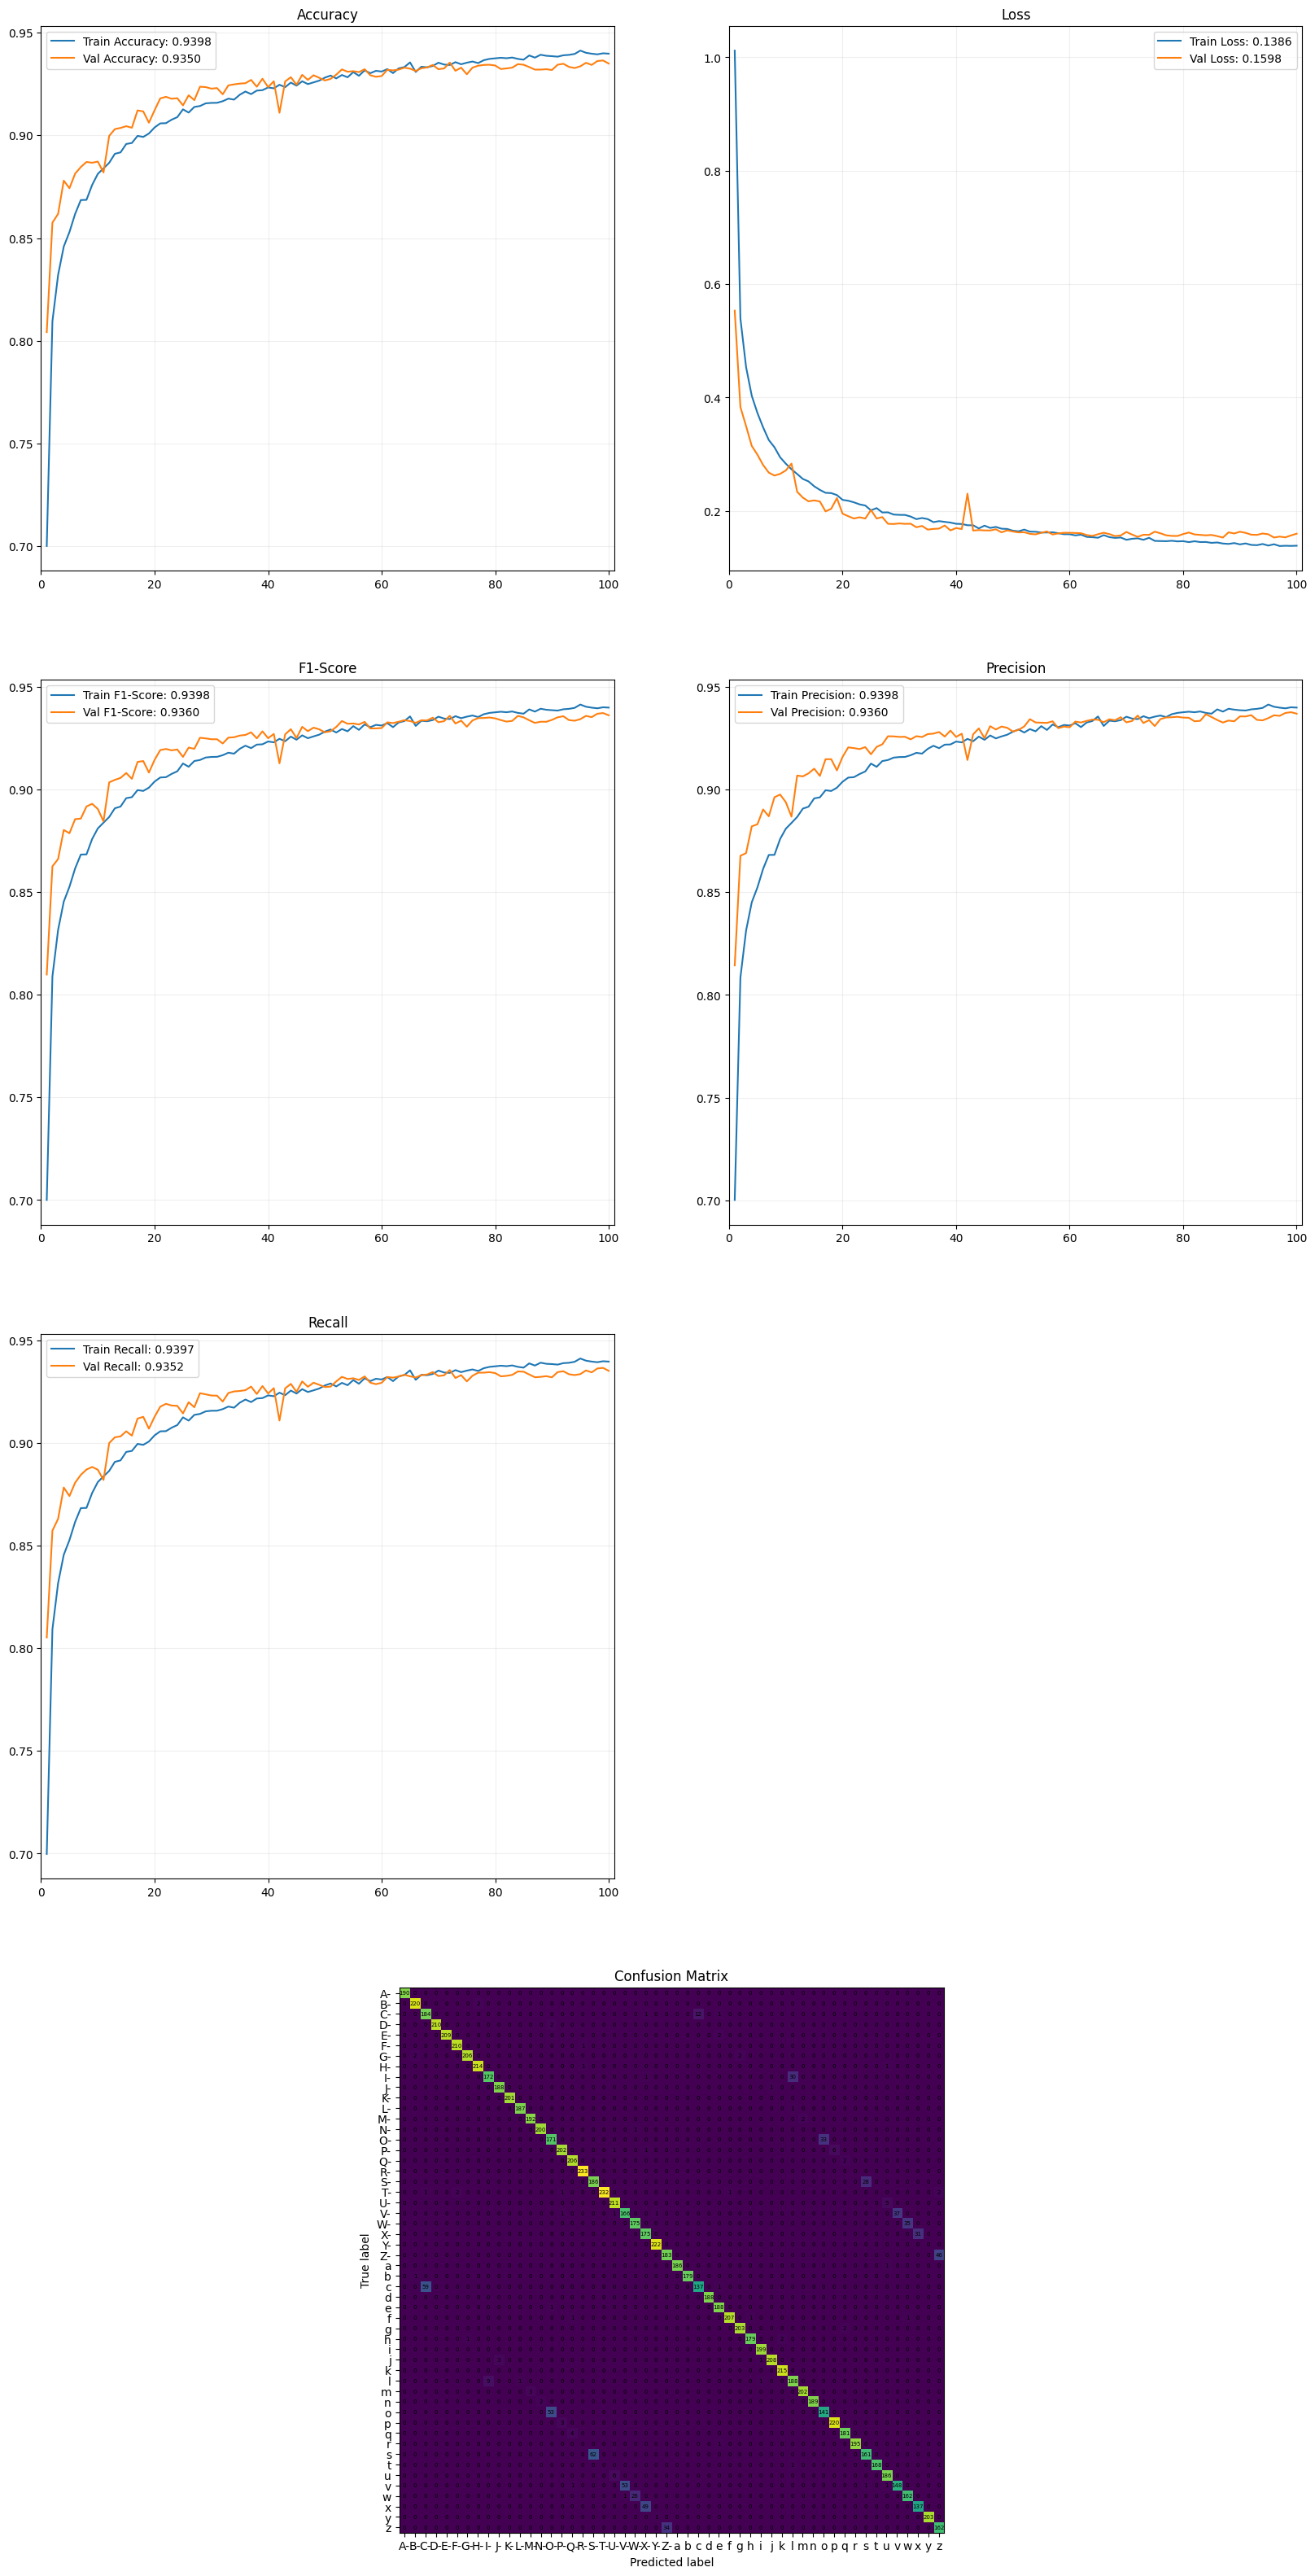

Epoch [100/100] 
Train Loss: 0.1386 
Val Loss: 0.1598 
Best Accuracy: 0.94 
Training Time: 14.56 seconds 
Early Stopping: 1


<Figure size 640x480 with 0 Axes>

In [22]:
models_dir = root_path / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_fn = custom_cnn
model = model_fn().to(DEVICE)
model_name = model_fn.__name__
print(model_name)

cur_model_dir = models_dir / model_name
cur_model_dir.mkdir(parents=True, exist_ok=True)

csv_file_path = cur_model_dir / f"{model_name}.csv"
model_file_path = cur_model_dir / f"{model_name}.pth"
best_model_file_path = cur_model_dir / f"best_{model_name}.pth"


metrics = [
    "epoch", "train_loss", 
    "val_loss", "train_accuracy", 
    "val_accuracy", "train_precision", 
    "val_precision", "train_recall", 
    "val_recall", "train_f1", 
    "val_f1", "early_stop",
    "train_time"
    ]

train_setup = TrainSetup(model, LEARNING_RATE, class_names, EPOCHS, DEVICE)
train_setup.begin_training(train_loader, val_loader, csv_file_path, model_file_path, best_model_file_path, metrics)